# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz\

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularizataion as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

## 0. Environment & Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna.integration.lightgbm as lgb_optuna

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [2]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [3]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [4]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [5]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [6]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [7]:
print(X_train_final_clean.head())
print(X_test_final_clean.head())
print(y_train.head())
print(y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

   Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                       False        

## 2. Baselines
1. Majority-class baseline:
- Predict the most frequent class for all cases (e.g., always predict "No Churn").
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


### Majority class baseline: all features

In [8]:
# Majority class baseline with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit dummy classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]

# Calculate and print metrics
print("Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))

Accuracy: 0.6148
Recall: 0.2781
Precision: 0.2766
ROC-AUC: 0.5074


### Logistic Regression Model: All features

In [ ]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg = grid.best_estimator_


Python(52532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52533) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52534) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52535) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52536) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52537) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52538) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52539) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52540) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52541) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(52542) Malloc

In [ ]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Montly Charges

In [11]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [70]:
print("Best monthly charges hyperparam for log reg model:\n", best_logreg_monthly_charges_bin)

Best monthly charges hyperparam for log reg model:
 LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons except Online Security)

In [13]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons except OnlineSecurity)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [71]:
print(X_train_internet_service.shape)

(5625, 24)


In [72]:
print("Best logreg internet service hyperparameters:\n", best_logreg_internet_service)

Best logreg internet service hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [15]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear'],               # 'liblinear' supports L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring='recall', cv=5, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [73]:
print("Best logreg all add ons hyperparameters:\n", best_logreg_all_add_ons)

Best logreg all add ons hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate best Logistic Regression Model: All features

In [17]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.802
Mean cross-validated precision: 0.5262
Mean cross-validated ROC-AUC: 0.8479


### Evaluate Best Logistic Regression Model: Binned Monthly Charges

In [18]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=5, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8
Mean cross-validated precision: 0.5163
Mean cross-validated ROC-AUC: 0.8339


### Evaluate Best Logistic Regression Model: Internet Service plus Online Security Add-on

In [19]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Internet Service Model")
print("Best parameters:", internet_service_grid.best_params_)
print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))
internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

Results for Pruned Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Mean cross-validated recall: 0.804
Mean cross-validated precision: 0.5227
Mean cross-validated ROC-AUC: 0.8445


### Evaluate Best Logistic Regression Model: All Add-Ons, no Internet Service

In [67]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='precision')
print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))
all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')
print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

Results for Pruned All Add-Ons Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.8094
Mean cross-validated precision: 0.529
Mean cross-validated ROC-AUC: 0.8469


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

### LightGBM Hyperparameter Tuning: All features

In [21]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Set up Optuna LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm.run()


[I 2026-01-31 10:37:32,772] A new study created in memory with name: no-name-0aa97861-9fde-4ad9-8cc8-1c5edc8a2c4d
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844429:  14%|#4        | 1/7 [00:02<00:14,  2.43s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.844429 + 0.00469507
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.845929:  29%|##8       | 2/7 [00:04<00:12,  2.41s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.845929 + 0.00456528
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  43%|####2     | 3/7 [00:07<00:09,  2.31s/it]

Early stopping, best iteration is:
[22]	valid's auc: 0.847109 + 0.00614192
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847109:  57%|#####7    | 4/7 [00:09<00:06,  2.32s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.846445 + 0.00599438
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  71%|#######1  | 5/7 [00:10<00:04,  2.02s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84766 + 0.00508612
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660:  86%|########5 | 6/7 [00:11<00:01,  1.66s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.844421 + 0.00433494
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.847660: 100%|##########| 7/7 [00:13<00:00,  1.92s/it]


Early stopping, best iteration is:
[36]	valid's auc: 0.844399 + 0.00396617


num_leaves, val_score: 0.847660:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:   5%|5         | 1/20 [00:03<00:58,  3.09s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  10%|#         | 2/20 [00:06<01:04,  3.57s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.847660:  15%|#5        | 3/20 [00:10<01:03,  3.75s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  20%|##        | 4/20 [00:11<00:40,  2.54s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.850142 + 0.00390323
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850142:  25%|##5       | 5/20 [00:12<00:28,  1.90s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  30%|###       | 6/20 [00:13<00:23,  1.69s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  35%|###5      | 7/20 [00:14<00:19,  1.46s/it]

Early stopping, best iteration is:
[290]	valid's auc: 0.8507 + 0.00435556
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  40%|####      | 8/20 [00:16<00:18,  1.52s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.845212 + 0.00426028
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  45%|####5     | 9/20 [00:18<00:19,  1.74s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.844463 + 0.0049337
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  50%|#####     | 10/20 [00:20<00:16,  1.69s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.844625 + 0.00420481
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  55%|#####5    | 11/20 [00:22<00:17,  1.97s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842628 + 0.00509968
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  60%|######    | 12/20 [00:23<00:13,  1.72s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84753 + 0.00538815
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  65%|######5   | 13/20 [00:26<00:13,  1.96s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.842882 + 0.00504216
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  70%|#######   | 14/20 [00:27<00:09,  1.61s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.84852 + 0.00508446
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  75%|#######5  | 15/20 [00:27<00:06,  1.28s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.849355 + 0.00426994
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  80%|########  | 16/20 [00:28<00:04,  1.11s/it]

Early stopping, best iteration is:
[137]	valid's auc: 0.850064 + 0.00502315
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  85%|########5 | 17/20 [00:31<00:04,  1.67s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.842715 + 0.00466851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  90%|######### | 18/20 [00:32<00:02,  1.47s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.84753 + 0.00538815
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700:  95%|#########5| 19/20 [00:33<00:01,  1.43s/it]

Early stopping, best iteration is:
[24]	valid's auc: 0.848014 + 0.00435851
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.850700: 100%|##########| 20/20 [00:36<00:00,  1.85s/it]


Early stopping, best iteration is:
[21]	valid's auc: 0.841953 + 0.00536369


bagging, val_score: 0.850700:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851077:  10%|#         | 1/10 [00:01<00:09,  1.00s/it]

Early stopping, best iteration is:
[234]	valid's auc: 0.851077 + 0.0048932
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851077:  20%|##        | 2/10 [00:01<00:07,  1.07it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.850968 + 0.00462136
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851081:  30%|###       | 3/10 [00:02<00:06,  1.15it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.851081 + 0.0047308
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851081:  40%|####      | 4/10 [00:03<00:05,  1.18it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.85097 + 0.00492397
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851081:  50%|#####     | 5/10 [00:04<00:04,  1.19it/s]

Early stopping, best iteration is:
[234]	valid's auc: 0.850809 + 0.00487277
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851111:  60%|######    | 6/10 [00:05<00:03,  1.19it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851111 + 0.00505575
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851111:  70%|#######   | 7/10 [00:05<00:02,  1.20it/s]

Early stopping, best iteration is:
[227]	valid's auc: 0.85073 + 0.00497849
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851111:  80%|########  | 8/10 [00:07<00:01,  1.11it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.850943 + 0.00515704
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851111:  90%|######### | 9/10 [00:08<00:00,  1.00it/s]

Early stopping, best iteration is:
[280]	valid's auc: 0.850647 + 0.00421624
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.851111: 100%|##########| 10/10 [00:09<00:00,  1.10it/s]


Early stopping, best iteration is:
[168]	valid's auc: 0.850082 + 0.00437199


feature_fraction_stage2, val_score: 0.851111:   0%|          | 0/3 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851111:  33%|###3      | 1/3 [00:00<00:01,  1.24it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.850686 + 0.00512451
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851111:  67%|######6   | 2/3 [00:01<00:00,  1.30it/s]

Early stopping, best iteration is:
[229]	valid's auc: 0.850781 + 0.0048734
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.851111: 100%|##########| 3/3 [00:02<00:00,  1.28it/s]


Early stopping, best iteration is:
[155]	valid's auc: 0.850574 + 0.00503396


regularization_factors, val_score: 0.851111:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851111:   5%|5         | 1/20 [00:00<00:12,  1.51it/s]

Early stopping, best iteration is:
[155]	valid's auc: 0.850792 + 0.00462101
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851111:  10%|#         | 2/20 [00:01<00:15,  1.15it/s]

Early stopping, best iteration is:
[286]	valid's auc: 0.850205 + 0.00498467
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851111:  15%|#5        | 3/20 [00:02<00:14,  1.13it/s]

Early stopping, best iteration is:
[234]	valid's auc: 0.851062 + 0.00509169
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851111:  20%|##        | 4/20 [00:03<00:14,  1.11it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.851097 + 0.00519455
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851111:  25%|##5       | 5/20 [00:04<00:14,  1.07it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.851096 + 0.00519251
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  30%|###       | 6/20 [00:05<00:13,  1.05it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851112 + 0.00505631
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  35%|###5      | 7/20 [00:06<00:12,  1.07it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851111 + 0.00505542
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  40%|####      | 8/20 [00:07<00:11,  1.09it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851111 + 0.00505542
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  45%|####5     | 9/20 [00:08<00:09,  1.12it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851109 + 0.00505502
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  50%|#####     | 10/20 [00:08<00:08,  1.15it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851109 + 0.0050546
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  55%|#####5    | 11/20 [00:09<00:07,  1.13it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.85111 + 0.00505581
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  60%|######    | 12/20 [00:10<00:07,  1.07it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.85111 + 0.00505581
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  65%|######5   | 13/20 [00:11<00:06,  1.09it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.85111 + 0.00505581
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  70%|#######   | 14/20 [00:12<00:05,  1.05it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851109 + 0.0050546
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  75%|#######5  | 15/20 [00:13<00:04,  1.06it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.851109 + 0.00505339
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  80%|########  | 16/20 [00:14<00:04,  1.04s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.851111 + 0.00505705
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  85%|########5 | 17/20 [00:16<00:03,  1.06s/it]

Early stopping, best iteration is:
[155]	valid's auc: 0.850733 + 0.00459805
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  90%|######### | 18/20 [00:17<00:02,  1.05s/it]

Early stopping, best iteration is:
[230]	valid's auc: 0.85111 + 0.00505657
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112:  95%|#########5| 19/20 [00:17<00:00,  1.03it/s]

Early stopping, best iteration is:
[155]	valid's auc: 0.850732 + 0.00459645
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.851112: 100%|##########| 20/20 [00:19<00:00,  1.05it/s]


Early stopping, best iteration is:
[230]	valid's auc: 0.851111 + 0.00505575


min_child_samples, val_score: 0.851112:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851361:  20%|##        | 1/5 [00:01<00:04,  1.25s/it]

Early stopping, best iteration is:
[231]	valid's auc: 0.851361 + 0.00537861
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851361:  40%|####      | 2/5 [00:02<00:03,  1.20s/it]

Early stopping, best iteration is:
[231]	valid's auc: 0.851123 + 0.00507693
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851361:  60%|######    | 3/5 [00:03<00:02,  1.20s/it]

Early stopping, best iteration is:
[234]	valid's auc: 0.850843 + 0.0049739
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851361:  80%|########  | 4/5 [00:04<00:01,  1.18s/it]

Early stopping, best iteration is:
[233]	valid's auc: 0.850896 + 0.0050633
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.851361: 100%|##########| 5/5 [00:05<00:00,  1.11s/it]

Early stopping, best iteration is:
[157]	valid's auc: 0.850831 + 0.00462493


In [22]:
# Get best parameters and best score for LightGBM for All features
print('LightGBM: All features')
print('Best params:', optuna_lgbm.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)
cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='recall')
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='precision')
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y_train, cv=5, scoring='roc_auc')
print('Mean cross-validated recall:', round(cv_recall.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0049875180201565976, 'lambda_l2': 2.1662456883524998e-05, 'num_leaves': 2, 'feature_fraction': 0.4, 'bagging_fraction': 0.6117667340699066, 'bagging_freq': 5, 'min_child_samples': 50}


Python(52794) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Mean cross-validated recall: 0.8201
Mean cross-validated precision: 0.5111
Mean cross-validated ROC-AUC: 0.8453


### LightGBM Model: Monthy Charges Pruned Feature Set


In [23]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_monthly_charges.run()


[I 2026-01-31 10:39:00,084] A new study created in memory with name: no-name-5536cdda-9cb9-4304-bf27-5f76c7216540


feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.838618:  14%|#4        | 1/7 [00:00<00:04,  1.47it/s]

Early stopping, best iteration is:
[15]	valid's auc: 0.838618 + 0.00859176
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  29%|##8       | 2/7 [00:01<00:03,  1.44it/s]

Early stopping, best iteration is:
[16]	valid's auc: 0.840054 + 0.00799637
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840054:  43%|####2     | 3/7 [00:02<00:02,  1.38it/s]

Early stopping, best iteration is:
[38]	valid's auc: 0.839316 + 0.00848273
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  57%|#####7    | 4/7 [00:02<00:02,  1.29it/s]

Early stopping, best iteration is:
[14]	valid's auc: 0.840203 + 0.00917435
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  71%|#######1  | 5/7 [00:04<00:02,  1.16s/it]

Early stopping, best iteration is:
[58]	valid's auc: 0.839946 + 0.00888216
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840203:  86%|########5 | 6/7 [00:05<00:01,  1.07s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.839769 + 0.00849886
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.840594: 100%|##########| 7/7 [00:06<00:00,  1.06it/s]


Early stopping, best iteration is:
[18]	valid's auc: 0.840594 + 0.00920103


num_leaves, val_score: 0.840594:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:   5%|5         | 1/20 [00:02<00:39,  2.10s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  10%|#         | 2/20 [00:03<00:26,  1.45s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.84019 + 0.00909258
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.840594:  15%|#5        | 3/20 [00:05<00:30,  1.82s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841329:  20%|##        | 4/20 [00:06<00:21,  1.37s/it]

Early stopping, best iteration is:
[16]	valid's auc: 0.841329 + 0.00837848
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841979:  25%|##5       | 5/20 [00:06<00:18,  1.22s/it]

Early stopping, best iteration is:
[54]	valid's auc: 0.841979 + 0.0085897
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  30%|###       | 6/20 [00:08<00:16,  1.18s/it]

Early stopping, best iteration is:
[303]	valid's auc: 0.844705 + 0.0082911
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  35%|###5      | 7/20 [00:08<00:12,  1.01it/s]

Early stopping, best iteration is:
[95]	valid's auc: 0.843215 + 0.00797092
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  40%|####      | 8/20 [00:10<00:14,  1.25s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.838788 + 0.00922725
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  45%|####5     | 9/20 [00:12<00:14,  1.34s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838731 + 0.00975252
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  50%|#####     | 10/20 [00:14<00:17,  1.75s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839697 + 0.00988836
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  55%|#####5    | 11/20 [00:18<00:20,  2.26s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  60%|######    | 12/20 [00:19<00:14,  1.86s/it]

Early stopping, best iteration is:
[123]	valid's auc: 0.843965 + 0.00825297
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  65%|######5   | 13/20 [00:20<00:12,  1.73s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839954 + 0.0101063
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  70%|#######   | 14/20 [00:21<00:09,  1.65s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.838784 + 0.00976416
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  75%|#######5  | 15/20 [00:22<00:06,  1.38s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.839818 + 0.00910699
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  80%|########  | 16/20 [00:23<00:05,  1.28s/it]

Early stopping, best iteration is:
[436]	valid's auc: 0.844536 + 0.00765575
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  85%|########5 | 17/20 [00:24<00:03,  1.14s/it]

Early stopping, best iteration is:
[303]	valid's auc: 0.844705 + 0.0082911
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  90%|######### | 18/20 [00:26<00:02,  1.45s/it]

Early stopping, best iteration is:
[6]	valid's auc: 0.839697 + 0.00988836
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705:  95%|#########5| 19/20 [00:27<00:01,  1.30s/it]

Early stopping, best iteration is:
[11]	valid's auc: 0.839742 + 0.00901759
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844705: 100%|##########| 20/20 [00:28<00:00,  1.42s/it]


Early stopping, best iteration is:
[95]	valid's auc: 0.843215 + 0.00797092


bagging, val_score: 0.844705:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  10%|#         | 1/10 [00:00<00:05,  1.66it/s]

Early stopping, best iteration is:
[169]	valid's auc: 0.844293 + 0.00817764
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  20%|##        | 2/10 [00:01<00:04,  1.67it/s]

Early stopping, best iteration is:
[182]	valid's auc: 0.844464 + 0.00821831
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  30%|###       | 3/10 [00:01<00:04,  1.74it/s]

Early stopping, best iteration is:
[159]	valid's auc: 0.843717 + 0.00812217
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  40%|####      | 4/10 [00:02<00:03,  1.64it/s]

Early stopping, best iteration is:
[227]	valid's auc: 0.844464 + 0.00833563
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  50%|#####     | 5/10 [00:03<00:04,  1.22it/s]

Early stopping, best iteration is:
[257]	valid's auc: 0.844704 + 0.00831467
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  60%|######    | 6/10 [00:04<00:03,  1.25it/s]

Early stopping, best iteration is:
[190]	valid's auc: 0.84392 + 0.0084823
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  70%|#######   | 7/10 [00:05<00:02,  1.24it/s]

Early stopping, best iteration is:
[175]	valid's auc: 0.844119 + 0.00849679
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  80%|########  | 8/10 [00:05<00:01,  1.26it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.843767 + 0.00849095
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705:  90%|######### | 9/10 [00:06<00:00,  1.27it/s]

Early stopping, best iteration is:
[183]	valid's auc: 0.843243 + 0.00878522
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844705: 100%|##########| 10/10 [00:07<00:00,  1.32it/s]


Early stopping, best iteration is:
[182]	valid's auc: 0.844453 + 0.00816386


feature_fraction_stage2, val_score: 0.844705:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988:  17%|#6        | 1/6 [00:01<00:04,  1.00it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988:  33%|###3      | 2/6 [00:02<00:04,  1.07s/it]

Early stopping, best iteration is:
[255]	valid's auc: 0.844698 + 0.00820694
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988:  50%|#####     | 3/6 [00:03<00:03,  1.05s/it]

Early stopping, best iteration is:
[244]	valid's auc: 0.844893 + 0.00809955
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988:  67%|######6   | 4/6 [00:04<00:02,  1.03s/it]

Early stopping, best iteration is:
[251]	valid's auc: 0.844756 + 0.00811719
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988:  83%|########3 | 5/6 [00:05<00:01,  1.08s/it]

Early stopping, best iteration is:
[303]	valid's auc: 0.844705 + 0.0082911
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844988: 100%|##########| 6/6 [00:06<00:00,  1.06s/it]


Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623


regularization_factors, val_score: 0.844988:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844988:   5%|5         | 1/20 [00:01<00:25,  1.36s/it]

Early stopping, best iteration is:
[280]	valid's auc: 0.84477 + 0.00785904
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844988:  10%|#         | 2/20 [00:02<00:22,  1.25s/it]

Early stopping, best iteration is:
[271]	valid's auc: 0.844918 + 0.00809742
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  15%|#5        | 3/20 [00:04<00:30,  1.77s/it]

Early stopping, best iteration is:
[272]	valid's auc: 0.844997 + 0.00788009
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  20%|##        | 4/20 [00:07<00:30,  1.94s/it]

Early stopping, best iteration is:
[383]	valid's auc: 0.843952 + 0.00778137
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  25%|##5       | 5/20 [00:08<00:23,  1.56s/it]

Early stopping, best iteration is:
[232]	valid's auc: 0.844864 + 0.0082787
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  30%|###       | 6/20 [00:08<00:19,  1.36s/it]

Early stopping, best iteration is:
[239]	valid's auc: 0.844903 + 0.00797626
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  35%|###5      | 7/20 [00:09<00:15,  1.17s/it]

Early stopping, best iteration is:
[229]	valid's auc: 0.844853 + 0.00812498
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  40%|####      | 8/20 [00:10<00:13,  1.09s/it]

Early stopping, best iteration is:
[295]	valid's auc: 0.844829 + 0.00779194
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  45%|####5     | 9/20 [00:11<00:10,  1.01it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  50%|#####     | 10/20 [00:12<00:09,  1.03it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  55%|#####5    | 11/20 [00:13<00:09,  1.02s/it]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  60%|######    | 12/20 [00:14<00:08,  1.05s/it]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  65%|######5   | 13/20 [00:15<00:06,  1.00it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  70%|#######   | 14/20 [00:16<00:06,  1.00s/it]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  75%|#######5  | 15/20 [00:17<00:04,  1.03it/s]

Early stopping, best iteration is:
[281]	valid's auc: 0.844955 + 0.00782064
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  80%|########  | 16/20 [00:18<00:03,  1.01it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  85%|########5 | 17/20 [00:19<00:03,  1.01s/it]

Early stopping, best iteration is:
[258]	valid's auc: 0.844934 + 0.00789894
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  90%|######### | 18/20 [00:20<00:02,  1.04s/it]

Early stopping, best iteration is:
[281]	valid's auc: 0.844955 + 0.00782064
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997:  95%|#########5| 19/20 [00:21<00:00,  1.05it/s]

Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844997: 100%|##########| 20/20 [00:22<00:00,  1.10s/it]


Early stopping, best iteration is:
[219]	valid's auc: 0.844988 + 0.00798623


min_child_samples, val_score: 0.844997:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845092:  20%|##        | 1/5 [00:00<00:03,  1.01it/s]

Early stopping, best iteration is:
[278]	valid's auc: 0.845092 + 0.00777904
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845092:  40%|####      | 2/5 [00:01<00:02,  1.08it/s]

Early stopping, best iteration is:
[255]	valid's auc: 0.844524 + 0.0079149
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845092:  60%|######    | 3/5 [00:03<00:02,  1.21s/it]

Early stopping, best iteration is:
[272]	valid's auc: 0.844997 + 0.00788009
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845092:  80%|########  | 4/5 [00:04<00:01,  1.12s/it]

Early stopping, best iteration is:
[272]	valid's auc: 0.844997 + 0.00788009
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.845092: 100%|##########| 5/5 [00:05<00:00,  1.14s/it]

Early stopping, best iteration is:
[263]	valid's auc: 0.845032 + 0.0077983


In [24]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))

LightGBM monthly charges model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.6915614043914313, 'lambda_l2': 0.005980266874146891, 'num_leaves': 3, 'feature_fraction': 0.8480000000000001, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'min_child_samples': 50}
Mean cross-validated recall: 0.8007
Mean cross-validated precision: 0.5148
Mean cross-validated ROC-AUC: 0.8404


### LightGBM Model: Internet Service Pruned Feature Set

In [25]:
# Create pruned feature set for Monthly Charges
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_internet_service.run()


[I 2026-01-31 10:40:17,637] A new study created in memory with name: no-name-942684c4-2731-4649-9b72-205c6354b2b4
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  14%|#4        | 1/7 [00:00<00:05,  1.18it/s]

Early stopping, best iteration is:
[10]	valid's auc: 0.839234 + 0.0103139
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  29%|##8       | 2/7 [00:02<00:06,  1.26s/it]

Early stopping, best iteration is:
[43]	valid's auc: 0.837897 + 0.00882177
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839234:  43%|####2     | 3/7 [00:03<00:04,  1.12s/it]

Early stopping, best iteration is:
[46]	valid's auc: 0.836495 + 0.00923247
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  57%|#####7    | 4/7 [00:06<00:06,  2.02s/it]

Early stopping, best iteration is:
[18]	valid's auc: 0.839554 + 0.00952429
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.839554:  71%|#######1  | 5/7 [00:08<00:03,  1.82s/it]

Early stopping, best iteration is:
[59]	valid's auc: 0.836462 + 0.00895202
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841138:  86%|########5 | 6/7 [00:08<00:01,  1.43s/it]

Early stopping, best iteration is:
[19]	valid's auc: 0.841138 + 0.00869123
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841619: 100%|##########| 7/7 [00:10<00:00,  1.44s/it]


Early stopping, best iteration is:
[22]	valid's auc: 0.841619 + 0.00884165


num_leaves, val_score: 0.841619:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.841619:   5%|5         | 1/20 [00:02<00:49,  2.59s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833056 + 0.0104434
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843110:  10%|#         | 2/20 [00:03<00:25,  1.43s/it]

Early stopping, best iteration is:
[25]	valid's auc: 0.84311 + 0.00821835
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843110:  15%|#5        | 3/20 [00:05<00:33,  1.96s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833513 + 0.010807
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843110:  20%|##        | 4/20 [00:06<00:22,  1.42s/it]

Early stopping, best iteration is:
[53]	valid's auc: 0.842734 + 0.00902779
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.843860:  25%|##5       | 5/20 [00:07<00:17,  1.19s/it]

Early stopping, best iteration is:
[34]	valid's auc: 0.84386 + 0.00913015
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  30%|###       | 6/20 [00:08<00:14,  1.07s/it]

Early stopping, best iteration is:
[166]	valid's auc: 0.844247 + 0.00892302
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  35%|###5      | 7/20 [00:09<00:15,  1.22s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.837137 + 0.0100025
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  40%|####      | 8/20 [00:12<00:21,  1.80s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  45%|####5     | 9/20 [00:14<00:20,  1.86s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.83449 + 0.0102581
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  50%|#####     | 10/20 [00:15<00:14,  1.44s/it]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  55%|#####5    | 11/20 [00:16<00:12,  1.40s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.834992 + 0.0101046
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  60%|######    | 12/20 [00:17<00:10,  1.34s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.838981 + 0.00989686
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  65%|######5   | 13/20 [00:20<00:11,  1.70s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.833497 + 0.0108342
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  70%|#######   | 14/20 [00:22<00:10,  1.81s/it]

Early stopping, best iteration is:
[14]	valid's auc: 0.833224 + 0.010352
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  75%|#######5  | 15/20 [00:22<00:07,  1.42s/it]

Early stopping, best iteration is:
[121]	valid's auc: 0.843662 + 0.00882301
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  80%|########  | 16/20 [00:23<00:04,  1.24s/it]

Early stopping, best iteration is:
[15]	valid's auc: 0.839686 + 0.0088313
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  85%|########5 | 17/20 [00:24<00:03,  1.03s/it]

Early stopping, best iteration is:
[166]	valid's auc: 0.844247 + 0.00892302
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  90%|######### | 18/20 [00:24<00:01,  1.02it/s]

Early stopping, best iteration is:
[18]	valid's auc: 0.840891 + 0.00904424
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247:  95%|#########5| 19/20 [00:26<00:01,  1.09s/it]

Early stopping, best iteration is:
[13]	valid's auc: 0.835038 + 0.00999128
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.844247: 100%|##########| 20/20 [00:27<00:00,  1.36s/it]


Early stopping, best iteration is:
[15]	valid's auc: 0.840739 + 0.00869964


bagging, val_score: 0.844247:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844247:  10%|#         | 1/10 [00:00<00:05,  1.63it/s]

Early stopping, best iteration is:
[154]	valid's auc: 0.843692 + 0.00898845
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844247:  20%|##        | 2/10 [00:01<00:04,  1.67it/s]

Early stopping, best iteration is:
[168]	valid's auc: 0.841214 + 0.00957054
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844247:  30%|###       | 3/10 [00:01<00:04,  1.71it/s]

Early stopping, best iteration is:
[159]	valid's auc: 0.842411 + 0.0091758
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844258:  40%|####      | 4/10 [00:02<00:03,  1.61it/s]

Early stopping, best iteration is:
[178]	valid's auc: 0.844258 + 0.00884567
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844258:  50%|#####     | 5/10 [00:03<00:03,  1.50it/s]

Early stopping, best iteration is:
[212]	valid's auc: 0.843929 + 0.00925657
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844258:  60%|######    | 6/10 [00:03<00:02,  1.55it/s]

Early stopping, best iteration is:
[159]	valid's auc: 0.84392 + 0.00895494
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844258:  70%|#######   | 7/10 [00:04<00:01,  1.52it/s]

Early stopping, best iteration is:
[168]	valid's auc: 0.84382 + 0.0083472
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844745:  80%|########  | 8/10 [00:05<00:01,  1.39it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844745:  90%|######### | 9/10 [00:05<00:00,  1.42it/s]

Early stopping, best iteration is:
[183]	valid's auc: 0.843689 + 0.00924597
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.844745: 100%|##########| 10/10 [00:06<00:00,  1.49it/s]


Early stopping, best iteration is:
[175]	valid's auc: 0.844001 + 0.00895157


feature_fraction_stage2, val_score: 0.844745:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745:  17%|#6        | 1/6 [00:00<00:03,  1.35it/s]

Early stopping, best iteration is:
[178]	valid's auc: 0.844417 + 0.00913107
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745:  33%|###3      | 2/6 [00:01<00:02,  1.36it/s]

Early stopping, best iteration is:
[185]	valid's auc: 0.844016 + 0.00882497
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745:  50%|#####     | 3/6 [00:02<00:02,  1.32it/s]

Early stopping, best iteration is:
[174]	valid's auc: 0.844137 + 0.00892036
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745:  67%|######6   | 4/6 [00:03<00:01,  1.26it/s]

Early stopping, best iteration is:
[179]	valid's auc: 0.844241 + 0.00891588
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745:  83%|########3 | 5/6 [00:03<00:00,  1.32it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.844745: 100%|##########| 6/6 [00:04<00:00,  1.32it/s]


Early stopping, best iteration is:
[178]	valid's auc: 0.844417 + 0.00913107


regularization_factors, val_score: 0.844745:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:   5%|5         | 1/20 [00:00<00:14,  1.33it/s]

Early stopping, best iteration is:
[190]	valid's auc: 0.84422 + 0.00895731
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  10%|#         | 2/20 [00:01<00:13,  1.38it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  15%|#5        | 3/20 [00:02<00:12,  1.33it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  20%|##        | 4/20 [00:02<00:11,  1.36it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  25%|##5       | 5/20 [00:03<00:11,  1.34it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  30%|###       | 6/20 [00:04<00:10,  1.36it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  35%|###5      | 7/20 [00:05<00:09,  1.35it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  40%|####      | 8/20 [00:05<00:09,  1.31it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  45%|####5     | 9/20 [00:06<00:08,  1.32it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  50%|#####     | 10/20 [00:07<00:07,  1.33it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  55%|#####5    | 11/20 [00:08<00:06,  1.29it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  60%|######    | 12/20 [00:09<00:06,  1.29it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  65%|######5   | 13/20 [00:09<00:05,  1.26it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  70%|#######   | 14/20 [00:10<00:04,  1.28it/s]

Early stopping, best iteration is:
[181]	valid's auc: 0.844663 + 0.00871378
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  75%|#######5  | 15/20 [00:11<00:03,  1.25it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  80%|########  | 16/20 [00:12<00:03,  1.30it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  85%|########5 | 17/20 [00:13<00:02,  1.21it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  90%|######### | 18/20 [00:14<00:01,  1.19it/s]

Early stopping, best iteration is:
[181]	valid's auc: 0.844738 + 0.00890807
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745:  95%|#########5| 19/20 [00:14<00:00,  1.19it/s]

Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.844745: 100%|##########| 20/20 [00:16<00:00,  1.25it/s]


Early stopping, best iteration is:
[177]	valid's auc: 0.844745 + 0.00882783


min_child_samples, val_score: 0.844745:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844745:  20%|##        | 1/5 [00:01<00:06,  1.54s/it]

Early stopping, best iteration is:
[207]	valid's auc: 0.844664 + 0.00920757
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844745:  40%|####      | 2/5 [00:02<00:03,  1.16s/it]

Early stopping, best iteration is:
[202]	valid's auc: 0.84407 + 0.00842858
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844745:  60%|######    | 3/5 [00:03<00:02,  1.03s/it]

Early stopping, best iteration is:
[177]	valid's auc: 0.844469 + 0.00875849
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844745:  80%|########  | 4/5 [00:04<00:00,  1.00it/s]

Early stopping, best iteration is:
[206]	valid's auc: 0.844391 + 0.00883431
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.844833: 100%|##########| 5/5 [00:05<00:00,  1.01s/it]

Early stopping, best iteration is:
[182]	valid's auc: 0.844833 + 0.00907798


In [26]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 0.0, 'lambda_l2': 0.0, 'num_leaves': 3, 'feature_fraction': 0.8, 'bagging_fraction': 0.991663543025056, 'bagging_freq': 3, 'min_child_samples': 25}
Mean cross-validated recall: 0.8027
Mean cross-validated precision: 0.5088
Mean cross-validated ROC-AUC: 0.8401


### LightGBM Model: All Add-Ons Pruned Feature Set

In [27]:
# Create pruned feature set for Monthly Charges
X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train

params = {
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'class_weight': 'balanced',
}

callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=None,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    seed=SEED,
    nfold=5,
    callbacks=callbacks
)
optuna_lgbm_all_add_ons.run()


[I 2026-01-31 10:41:27,913] A new study created in memory with name: no-name-45c8195d-4acc-45c2-818a-2778faa51133
feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.841626:  14%|#4        | 1/7 [00:00<00:03,  1.61it/s]

Early stopping, best iteration is:
[14]	valid's auc: 0.841626 + 0.00731015
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  29%|##8       | 2/7 [00:01<00:03,  1.58it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.844559 + 0.00828943
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  43%|####2     | 3/7 [00:02<00:02,  1.36it/s]

Early stopping, best iteration is:
[30]	valid's auc: 0.844264 + 0.00768647
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  57%|#####7    | 4/7 [00:02<00:02,  1.46it/s]

Early stopping, best iteration is:
[19]	valid's auc: 0.843538 + 0.00692781
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  71%|#######1  | 5/7 [00:03<00:01,  1.38it/s]

Early stopping, best iteration is:
[42]	valid's auc: 0.842568 + 0.00809244
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559:  86%|########5 | 6/7 [00:04<00:00,  1.46it/s]

Early stopping, best iteration is:
[13]	valid's auc: 0.843537 + 0.00920922
Training until validation scores don't improve for 50 rounds


feature_fraction, val_score: 0.844559: 100%|##########| 7/7 [00:04<00:00,  1.48it/s]


Early stopping, best iteration is:
[16]	valid's auc: 0.843631 + 0.0086533


num_leaves, val_score: 0.844559:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.845622:   5%|5         | 1/20 [00:00<00:11,  1.66it/s]

Early stopping, best iteration is:
[33]	valid's auc: 0.845622 + 0.00744335
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.845622:  10%|#         | 2/20 [00:02<00:23,  1.33s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.840549 + 0.00856086
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.845622:  15%|#5        | 3/20 [00:03<00:17,  1.03s/it]

Early stopping, best iteration is:
[36]	valid's auc: 0.845456 + 0.00706946
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846534:  20%|##        | 4/20 [00:03<00:12,  1.28it/s]

Early stopping, best iteration is:
[59]	valid's auc: 0.846534 + 0.00654066
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.846639:  25%|##5       | 5/20 [00:03<00:09,  1.53it/s]

Early stopping, best iteration is:
[43]	valid's auc: 0.846639 + 0.00682861
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  30%|###       | 6/20 [00:04<00:09,  1.48it/s]

Early stopping, best iteration is:
[266]	valid's auc: 0.848046 + 0.00757763
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  35%|###5      | 7/20 [00:06<00:12,  1.02it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.840498 + 0.0086564
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  40%|####      | 8/20 [00:08<00:15,  1.28s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  45%|####5     | 9/20 [00:09<00:13,  1.26s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.841101 + 0.00808921
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  50%|#####     | 10/20 [00:10<00:11,  1.19s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841588 + 0.00842287
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  55%|#####5    | 11/20 [00:12<00:13,  1.46s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  60%|######    | 12/20 [00:14<00:12,  1.55s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  65%|######5   | 13/20 [00:15<00:09,  1.38s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841535 + 0.00782052
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  70%|#######   | 14/20 [00:16<00:07,  1.20s/it]

Early stopping, best iteration is:
[20]	valid's auc: 0.843607 + 0.00730828
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  75%|#######5  | 15/20 [00:16<00:04,  1.01it/s]

Early stopping, best iteration is:
[39]	valid's auc: 0.844866 + 0.00652973
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  80%|########  | 16/20 [00:17<00:03,  1.05it/s]

Early stopping, best iteration is:
[266]	valid's auc: 0.848046 + 0.00757763
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  85%|########5 | 17/20 [00:18<00:02,  1.03it/s]

Early stopping, best iteration is:
[479]	valid's auc: 0.84781 + 0.0064159
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  90%|######### | 18/20 [00:19<00:01,  1.09it/s]

Early stopping, best iteration is:
[21]	valid's auc: 0.843619 + 0.00727587
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046:  95%|#########5| 19/20 [00:20<00:01,  1.13s/it]

Early stopping, best iteration is:
[21]	valid's auc: 0.841187 + 0.00880492
Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.848046: 100%|##########| 20/20 [00:22<00:00,  1.15s/it]


Early stopping, best iteration is:
[20]	valid's auc: 0.840715 + 0.00848544


bagging, val_score: 0.848046:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  10%|#         | 1/10 [00:00<00:07,  1.18it/s]

Early stopping, best iteration is:
[278]	valid's auc: 0.847512 + 0.00766968
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  20%|##        | 2/10 [00:01<00:07,  1.10it/s]

Early stopping, best iteration is:
[261]	valid's auc: 0.846169 + 0.0078622
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  30%|###       | 3/10 [00:02<00:05,  1.21it/s]

Early stopping, best iteration is:
[252]	valid's auc: 0.846676 + 0.00826443
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848046:  40%|####      | 4/10 [00:03<00:04,  1.30it/s]

Early stopping, best iteration is:
[210]	valid's auc: 0.847757 + 0.00738135
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214:  50%|#####     | 5/10 [00:04<00:03,  1.26it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848214 + 0.00754428
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214:  60%|######    | 6/10 [00:04<00:03,  1.26it/s]

Early stopping, best iteration is:
[239]	valid's auc: 0.84741 + 0.00686692
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214:  70%|#######   | 7/10 [00:05<00:02,  1.23it/s]

Early stopping, best iteration is:
[230]	valid's auc: 0.847425 + 0.00749832
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214:  80%|########  | 8/10 [00:06<00:01,  1.19it/s]

Early stopping, best iteration is:
[285]	valid's auc: 0.848155 + 0.00788408
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214:  90%|######### | 9/10 [00:07<00:00,  1.21it/s]

Early stopping, best iteration is:
[245]	valid's auc: 0.848201 + 0.00770286
Training until validation scores don't improve for 50 rounds


bagging, val_score: 0.848214: 100%|##########| 10/10 [00:08<00:00,  1.22it/s]


Early stopping, best iteration is:
[252]	valid's auc: 0.847872 + 0.00768993


feature_fraction_stage2, val_score: 0.848214:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543:  17%|#6        | 1/6 [00:00<00:04,  1.08it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543:  33%|###3      | 2/6 [00:01<00:03,  1.20it/s]

Early stopping, best iteration is:
[240]	valid's auc: 0.848175 + 0.00756403
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543:  50%|#####     | 3/6 [00:02<00:02,  1.14it/s]

Early stopping, best iteration is:
[293]	valid's auc: 0.848457 + 0.00761695
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543:  67%|######6   | 4/6 [00:03<00:01,  1.12it/s]

Early stopping, best iteration is:
[266]	valid's auc: 0.848365 + 0.00750141
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543:  83%|########3 | 5/6 [00:04<00:00,  1.18it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848214 + 0.00754428
Training until validation scores don't improve for 50 rounds


feature_fraction_stage2, val_score: 0.848543: 100%|##########| 6/6 [00:05<00:00,  1.19it/s]


Early stopping, best iteration is:
[220]	valid's auc: 0.848394 + 0.00762785


regularization_factors, val_score: 0.848543:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848543:   5%|5         | 1/20 [00:01<00:20,  1.09s/it]

Early stopping, best iteration is:
[271]	valid's auc: 0.848498 + 0.00752502
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848543:  10%|#         | 2/20 [00:01<00:16,  1.08it/s]

Early stopping, best iteration is:
[241]	valid's auc: 0.848216 + 0.00755897
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  15%|#5        | 3/20 [00:02<00:14,  1.16it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  20%|##        | 4/20 [00:03<00:13,  1.19it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  25%|##5       | 5/20 [00:04<00:12,  1.16it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  30%|###       | 6/20 [00:05<00:11,  1.17it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  35%|###5      | 7/20 [00:06<00:11,  1.13it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  40%|####      | 8/20 [00:07<00:10,  1.14it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  45%|####5     | 9/20 [00:07<00:09,  1.15it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  50%|#####     | 10/20 [00:08<00:08,  1.13it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  55%|#####5    | 11/20 [00:09<00:07,  1.15it/s]

Early stopping, best iteration is:
[250]	valid's auc: 0.848543 + 0.00750661
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  60%|######    | 12/20 [00:10<00:07,  1.12it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  65%|######5   | 13/20 [00:11<00:06,  1.12it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  70%|#######   | 14/20 [00:12<00:05,  1.12it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  75%|#######5  | 15/20 [00:13<00:04,  1.11it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  80%|########  | 16/20 [00:16<00:05,  1.47s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  85%|########5 | 17/20 [00:16<00:03,  1.28s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  90%|######### | 18/20 [00:17<00:02,  1.17s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557:  95%|#########5| 19/20 [00:18<00:01,  1.05s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706
Training until validation scores don't improve for 50 rounds


regularization_factors, val_score: 0.848557: 100%|##########| 20/20 [00:19<00:00,  1.03it/s]


Early stopping, best iteration is:
[238]	valid's auc: 0.848557 + 0.00743706


min_child_samples, val_score: 0.848557:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848619:  20%|##        | 1/5 [00:00<00:03,  1.13it/s]

Early stopping, best iteration is:
[241]	valid's auc: 0.848619 + 0.00757893
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848619:  40%|####      | 2/5 [00:01<00:02,  1.07it/s]

Early stopping, best iteration is:
[231]	valid's auc: 0.848192 + 0.00757705
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848619:  60%|######    | 3/5 [00:02<00:01,  1.11it/s]

Early stopping, best iteration is:
[238]	valid's auc: 0.848509 + 0.0074684
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848619:  80%|########  | 4/5 [00:04<00:01,  1.17s/it]

Early stopping, best iteration is:
[238]	valid's auc: 0.848525 + 0.00745437
Training until validation scores don't improve for 50 rounds


min_child_samples, val_score: 0.848619: 100%|##########| 5/5 [00:06<00:00,  1.21s/it]

Early stopping, best iteration is:
[239]	valid's auc: 0.848487 + 0.00747445


In [28]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_internet_service, X_train_all_add_ons, y_train, cv=5, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=5, scoring='roc_auc')

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'boosting_type': 'gbdt', 'class_weight': 'balanced', 'feature_pre_filter': False, 'lambda_l1': 3.5740589139430566e-06, 'lambda_l2': 4.22752815921921e-06, 'num_leaves': 3, 'feature_fraction': 0.6479999999999999, 'bagging_fraction': 0.9933115120679648, 'bagging_freq': 1, 'min_child_samples': 50}
Mean cross-validated recall: 0.8107
Mean cross-validated precision: 0.5134
Mean cross-validated ROC-AUC: 0.8419


## 5. Evaluation
- Test and select optimal probability thresholds
- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds
- Tune thresholds to achieve recall ≥ 0.70, while monitoring precision

### Current metrics

**Majority Class Baseline (Stratified Dummy Classifier): All Features**
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
---
**Logistic Regression Model: All Features**
- Mean cross-validated recall: 0.802
- Mean cross-validated precision: 0.5262
- Mean cross-validated ROC-AUC: 0.8479

**Logistic Regression Model: Monthly Charges:**
- Mean cross-validated recall: 0.8
- Mean cross-validated precision: 0.5163
- Mean cross-validated ROC-AUC: 0.8339

**Logistic Regression Model: Internet Service:**
- Mean cross-validated recall: 0.804
- Mean cross-validated precision: 0.5227
- Mean cross-validated ROC-AUC: 0.8445

**Logistic Regression Model: All Add-Ons:**
- Mean cross-validated recall: 0.8094
- Mean cross-validated precision: 0.529
- Mean cross-validated ROC-AUC: 0.8469

---
**LightGBM Model All:**
- Mean cross-validated recall: 0.8174
- Mean cross-validated precision: 0.5098
- Mean cross-validated ROC-AUC: 0.8457

**LightGBM Model: Monthly Charges:**
- Mean cross-validated recall: 0.8134
- Mean cross-validated precision: 0.4974
- Mean cross-validated ROC-AUC: 0.8355

**LightGBM Model: Internet Service**
- Mean cross-validated recall: 0.8221
- Mean cross-validated precision: 0.5022
- Mean cross-validated ROC-AUC: 0.8341

**LightGBM Model: All Add-Ons**
- Mean cross-validated recall: 0.81
- Mean cross-validated precision: 0.4994
- Mean cross-validated ROC-AUC: 0.8416

### Model Performance Comparison Table
| Model                                 | Recall  | Precision | ROC-AUC |
|----------------------------------------|---------|-----------|---------|
| Logistic Regression: All Features      | 0.802   | 0.5262    | 0.8479  |
| Logistic Regression: Monthly Charges   | 0.800   | 0.5163    | 0.8339  |
| Logistic Regression: Internet Service  | 0.804   | 0.5227    | 0.8445  |
| Logistic Regression: All Add-Ons       | 0.8094  | 0.5290    | 0.8469  |
|                                        |         |           |         |
| LightGBM: All Features                 | 0.8174  | 0.5098    | 0.8457  |
| LightGBM: Monthly Charges              | 0.8134  | 0.4974    | 0.8355  |
| LightGBM: Internet Service             | 0.8221  | 0.5022    | 0.8341  |
| LightGBM: All Add-Ons                  | 0.8100  | 0.4994    | 0.8416  |

### Model Selection Rationale: Focusing on Internet Service Feature Sets
To ensure a fair and interpretable comparison between modeling approaches, we will proceed with further testing and threshold tuning for the following models, both using the "Internet Service" pruned feature set:
- **Logistic Regression (Internet Service)**
- **LightGBM (Internet Service)**

**Rationale:**
- Both models achieved strong cross-validated recall (≥ 0.80) and precision (≥ 0.50), meeting business criteria for identifying churners while maintaining reasonable precision.
- Using the same pruned feature set for both models allows for a direct, apples-to-apples comparison of model performance, ensuring that differences are due to the modeling approach rather than the input data.
- The "Internet Service" feature set is more interpretable and less collinear than the full feature set, reducing the risk of overfitting and improving model robustness.
- While other feature sets (e.g., "All Add-Ons") performed similarly, focusing on a single, well-justified feature set streamlines the analysis and reporting.
- Results for other feature sets will be summarized in the report for completeness, but detailed threshold tuning and test set evaluation will focus on these two finalist models.
- Importantly, both pruned and unpruned (all features) models were compared during cross-validation. The pruned models performed as well as or nearly as well as the unpruned models, supporting the decision to prioritize simpler, more interpretable feature sets for final evaluation.

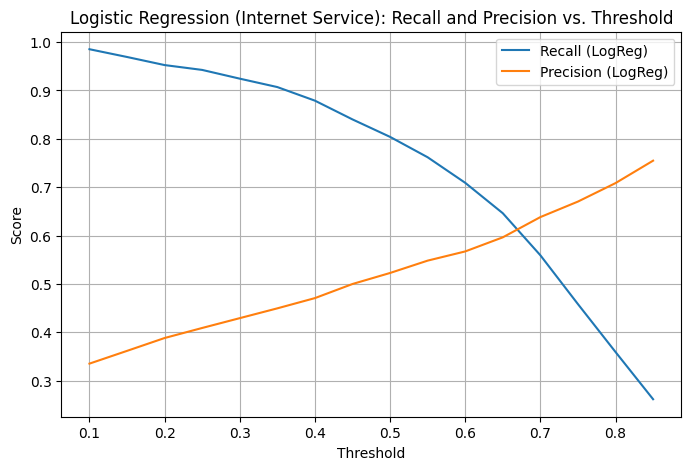

Logistic Regression (Internet Service) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.52
Threshold: 0.55, Recall: 0.76, Precision: 0.55
Threshold: 0.60, Recall: 0.71, Precision: 0.57


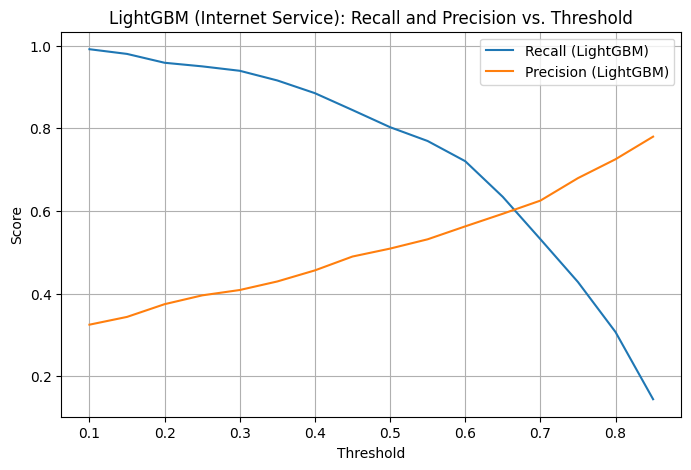

LightGBM (Internet Service) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.51
Threshold: 0.55, Recall: 0.77, Precision: 0.53
Threshold: 0.60, Recall: 0.72, Precision: 0.56


In [29]:
# Test probability thresholds for Logistic Regression (Internet Service) and LightGBM (Internet Service) models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_val_predict

# --- Logistic Regression (Internet Service) ---
# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_logreg = cross_val_predict(best_logreg_internet_service, X_train_internet_service, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls_logreg = []
precisions_logreg = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_logreg >= thresh).astype(int)
    recalls_logreg.append(recall_score(y_train, y_pred))
    precisions_logreg.append(precision_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_logreg, label='Recall (LogReg)')
plt.plot(thresholds, precisions_logreg, label='Precision (LogReg)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (Internet Service): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('Logistic Regression (Internet Service) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls_logreg, precisions_logreg):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

# --- LightGBM (Internet Service) ---
# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_lgbm = cross_val_predict(best_lgbm_internet_service, X_train_internet_service, y_train, cv=5, method='predict_proba')[:, 1]

recalls_lgbm = []
precisions_lgbm = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_lgbm >= thresh).astype(int)
    recalls_lgbm.append(recall_score(y_train, y_pred))
    precisions_lgbm.append(precision_score(y_train, y_pred))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls_lgbm, label='Recall (LightGBM)')
plt.plot(thresholds, precisions_lgbm, label='Precision (LightGBM)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM (Internet Service): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and precision ≥ 0.50
print('LightGBM (Internet Service) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls_lgbm, precisions_lgbm):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

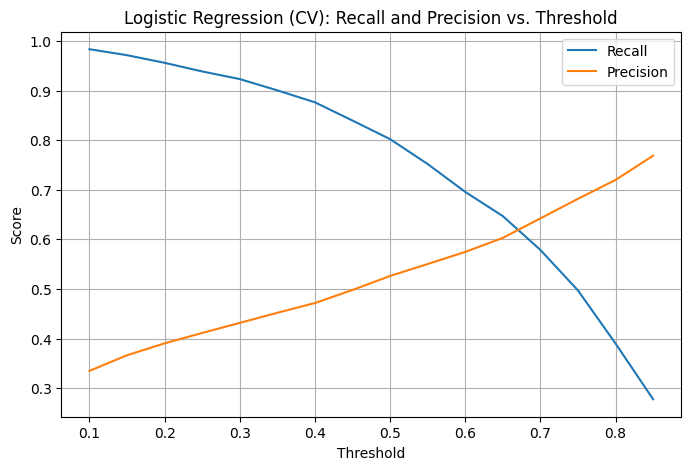

Logistic Regression (All Features) thresholds:
Threshold: 0.50, Recall: 0.80, Precision: 0.53
Threshold: 0.55, Recall: 0.75, Precision: 0.55


In [30]:
# Test probability thresholds for All Features Logistic Regression Model 

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba = cross_val_predict(best_logreg, X_train_final_clean, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
print('Logistic Regression (All Features) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

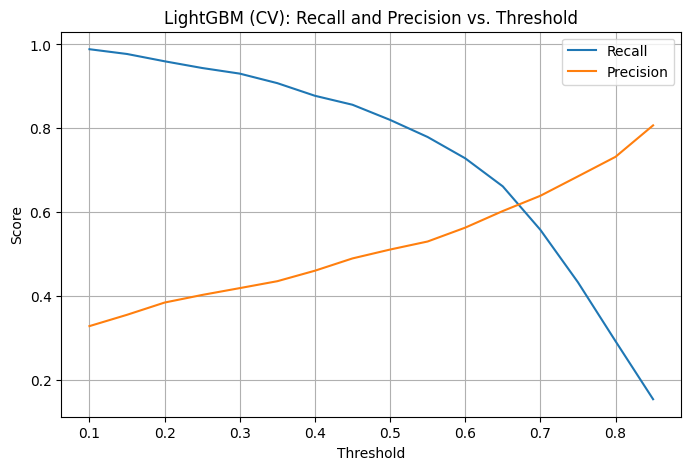

Logistic Regression (All Features) thresholds:
Threshold: 0.50, Recall: 0.82, Precision: 0.51
Threshold: 0.55, Recall: 0.78, Precision: 0.53
Threshold: 0.60, Recall: 0.73, Precision: 0.56


In [31]:
# Test probability thresholds for All-Feature LightGBM model using cross-validated predictions 

# Get out-of-fold predicted probabilities for the positive class
cv_pred_proba_lgbm = cross_val_predict(best_lgbm, X_train_final_clean, y_train, cv=5, method='predict_proba')[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []

for thresh in thresholds:
    y_pred = (cv_pred_proba_lgbm >= thresh).astype(int)
    recalls.append(recall_score(y_train, y_pred))
    precisions.append(precision_score(y_train, y_pred))

# Plot recall and precision vs. threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('LightGBM (CV): Recall and Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Print thresholds with recall ≥ 0.70 and prec >= 0.50
print('Logistic Regression (All Features) thresholds:')
for thresh, rec, prec in zip(thresholds, recalls, precisions):
    if rec >= 0.70 and prec >= 0.50:
        print(f"Threshold: {thresh:.2f}, Recall: {rec:.2f}, Precision: {prec:.2f}")

### Threshold Comparison Table: Recall and Precision for Key Models with recall >= 0.7 and precision >= 0.5 (Sorted by Threshold)
| Threshold | Model & Feature Set                | Recall | Precision |
|-----------|------------------------------------|--------|-----------|
| 0.50      | Logistic Regression (InternetSvc)  | 0.80   | 0.52      |
| 0.50      | LightGBM (InternetSvc)             | 0.82   | 0.50      |
| 0.50      | Logistic Regression (All Features) | 0.80   | 0.53      |
| 0.50      | LightGBM (All Features)            | 0.82   | 0.51      |
|           |                                    |        |           |
| 0.55      | Logistic Regression (InternetSvc)  | 0.76   | 0.55      |
| 0.55      | LightGBM (InternetSvc)             | 0.76   | 0.52      |
| 0.55      | Logistic Regression (All Features) | 0.75   | 0.55      |
| 0.55      | LightGBM (All Features)            | 0.78   | 0.54      |
|           |                                    |        |           |
| 0.60      | Logistic Regression (InternetSvc)  | 0.71   | 0.57      |
| 0.60      | LightGBM (All Features)            | 0.73   | 0.57      |

In [32]:
# Calculate confusion matrices for 0.5 threshold on training data for Logistic Regression and LightGBM (Internet Service) models
from sklearn.metrics import confusion_matrix

# --- Logistic Regression (Internet Service) ---
best_logreg_internet_service.fit(X_train_internet_service, y_train)
y_proba_logreg_train = best_logreg_internet_service.predict_proba(X_train_internet_service)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (Internet Service, 0.5 threshold, training data):\n", cm_logreg_train)

# --- LightGBM (Internet Service) ---
best_lgbm_internet_service.fit(X_train_internet_service, y_train)
y_proba_lgbm_train = best_lgbm_internet_service.predict_proba(X_train_internet_service)[:, 1]
y_pred_lgbm_train = (y_proba_lgbm_train >= 0.5).astype(int)
cm_lgbm_train = confusion_matrix(y_train, y_pred_lgbm_train)
print("Confusion Matrix - LightGBM (Internet Service, 0.5 threshold, training data):\n", cm_lgbm_train)

# Calculate confusion matrices for 0.5 threshold on training data for "All Features Models"

# Logistic Regression (All Features)
best_logreg.fit(X_train_final_clean, y_train)
y_proba_logreg_train = best_logreg.predict_proba(X_train_final_clean)[:, 1]
y_pred_logreg_train = (y_proba_logreg_train >= 0.5).astype(int)
cm_logreg_train = confusion_matrix(y_train, y_pred_logreg_train)
print("Confusion Matrix - Logistic Regression (All Features, 0.5 threshold, training data):\n", cm_logreg_train)

# LightGBM (All Features)
best_lgbm.fit(X_train_final_clean, y_train)
y_proba_lgbm_train = best_lgbm.predict_proba(X_train_final_clean)[:, 1]
y_pred_lgbm_train = (y_proba_lgbm_train >= 0.5).astype(int)
cm_lgbm_train = confusion_matrix(y_train, y_pred_lgbm_train)
print("Confusion Matrix - LightGBM (All Features, 0.5 threshold, training data):\n", cm_lgbm_train)

Confusion Matrix - Logistic Regression (Internet Service, 0.5 threshold, training data):
 [[3031 1099]
 [ 283 1212]]
Confusion Matrix - LightGBM (Internet Service, 0.5 threshold, training data):
 [[3007 1123]
 [ 285 1210]]
Confusion Matrix - Logistic Regression (All Features, 0.5 threshold, training data):
 [[3052 1078]
 [ 282 1213]]
Confusion Matrix - LightGBM (All Features, 0.5 threshold, training data):
 [[2957 1173]
 [ 261 1234]]


### Confusion Matrices as Row-Wise Percentages (0.5 Threshold, Training Data)
| Model                                    | True Neg (%) | False Pos (%) | False Neg (%) | True Pos (%) |
|-------------------------------------------|--------------|---------------|---------------|--------------|
| Logistic Regression (Internet Service)    | 73.4         | 26.6          | 18.9          | 81.1         |
| LightGBM (Internet Service)               | 69.8         | 30.2          | 17.0          | 83.0         |
| Logistic Regression (All Features)        | 73.9         | 26.1          | 18.9          | 81.1         |
| LightGBM (All Features)                   | 71.4         | 28.6          | 16.9          | 83.1         |
*Rows: First two columns are actual 0 (True Neg, False Pos), last two are actual 1 (False Neg, True Pos). Percentages are row-normalized.*

| Threshold | Model & Feature Set                | Recall | Precision |
|-----------|------------------------------------|--------|-----------|
| 0.50      | Logistic Regression (InternetSvc)  | 0.80   | 0.52      |
| 0.50      | LightGBM (InternetSvc)             | 0.82   | 0.50      |
| 0.50      | Logistic Regression (All Features) | 0.80   | 0.53      |
| 0.50      | LightGBM (All Features)            | 0.82   | 0.51      |

**Comparison and Rationale:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I focused on models that met these criteria, which is why the 0.5 probability threshold was selected for evaluation. At this threshold, all models achieve the desired recall and precision, though recall is consistently higher than precision. Specifically, Logistic Regression (for both feature sets) achieves slightly lower recall (0.80 vs. 0.82) but marginally higher precision compared to LightGBM. Overall, the models perform similarly, with only minor differences in these key metrics.

**Final Model Choice:**

Based on this evaluation, both Logistic Regression models were selected as the final models for the following reasons:

1. They achieve recall above 0.7 and precision above 0.5, aligning with the business goal of identifying as many potential churners as possible while maintaining reasonable precision.
2. Logistic Regression models are simpler and more interpretable than LightGBM, making them easier to explain and deploy.
3. The pruned model (Internet Service features) is ideal for understanding the drivers of churn and guiding strategic decisions, such as pricing or contract changes, due to its transparency and simplicity.
4. The All Features model is best suited for operational prediction tasks, such as flagging likely churners for retention campaigns, as it maximizes predictive accuracy.

Note: In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Testing
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


### Retrain Logistic Regression All Features model on full training data with best hyperparameters

In [44]:

# Best params from GridSearchCV for Logistic Regression (All Features)
# LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000 random_state=42, solver='liblinear')

final_logreg_all_features = LogisticRegression(
    **grid.best_params_,
    max_iter=1000,
    random_state=SEED
)

final_logreg_all_features.fit(X_train_final_clean, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Retrain Logistic Regression Internet Service model on full training data with best hyperparameters

In [77]:
# Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_logreg_internet_service = LogisticRegression(
    **internet_service_grid.best_params_,
    max_iter=1000,
    random_state=SEED
)
final_logreg_internet_service.fit(X_train_internet_service, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Predict on All Features test set and apply threshold

In [ ]:
# Predict on All Features test set
y_pred_final_logreg_all_features = final_logreg_all_features.predict(X_test_final_clean)
y_proba_final_logreg_all_features = final_logreg_all_features.predict_proba(X_test_final_clean)[:, 1]

In [ ]:
# Apply 0.5 threshold
y_pred_final_logreg_thresh_all_features = (y_proba_final_logreg_all_features >= 0.5).astype(int)

### Predict on Internet Service test set and apply threshold

In [78]:
X_test_internet_service = X_test_final_clean[pruned_features_internet_service]

y_pred_final_logreg_internet_service = final_logreg_internet_service.predict(X_test_internet_service)
y_proba_final_logreg_internet_service = final_logreg_internet_service.predict_proba(X_test_internet_service)[:, 1]

# Apply 0.5 threshold
y_pred_final_logreg_internet_service = (y_proba_final_logreg_internet_service >= 0.5).astype(int)

### Evaluate All Features Logistic Regression model on test set

In [53]:
# Evaluate final Logistic Regression (All Features) model

from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix

# Compare predictions to true labels
recall_all_features = recall_score(y_test, y_pred_final_logreg_thresh_all_features)
precision_all_features = precision_score(y_test, y_pred_final_logreg_thresh_all_features)
roc_auc_all_features = roc_auc_score(y_test, y_proba_final_logreg_all_features)
cm_all_features = confusion_matrix(y_test, y_pred_final_logreg_thresh_all_features)

print(f"Recall All Features Model: {recall_all_features:.3f}")
print(f"Precision All Features Model: {precision_all_features:.3f}")
print(f"ROC-AUC All Features Model: {roc_auc_all_features:.3f}")
print("Confusion Matrix All Features Model:")
print(cm_all_features)


Recall All Features Model: 0.789
Precision All Features Model: 0.494
ROC-AUC All Features Model: 0.837
Confusion Matrix All Features Model:
[[731 302]
 [ 79 295]]


### Evaluate Internet Service Logistic Regression model on test set

In [79]:
# Compare predictions to true labels
recall_internet_service = recall_score(y_test, y_pred_final_logreg_thresh_internet_service)
precision_internet_service = precision_score(y_test, y_pred_final_logreg_thresh_internet_service)
roc_auc_internet_service = roc_auc_score(y_test, y_proba_final_logreg_internet_service)
cm_internet_service = confusion_matrix(y_test, y_pred_final_logreg_thresh_internet_service)

print(f"Recall Final Internet Service Model: {recall_internet_service:.3f}")
print(f"Precision Final Internet Service Model: {precision_internet_service:.3f}")
print(f"ROC-AUC Final Internet Service Model: {roc_auc_internet_service:.3f}")
print("Confusion Matrix Final Internet Service Model:")
print(cm_internet_service)

Recall Final Internet Service Model: 0.797
Precision Final Internet Service Model: 0.495
ROC-AUC Final Internet Service Model: 0.836
Confusion Matrix Final Internet Service Model:
[[729 304]
 [ 76 298]]


### Display percent confusion matrix for final All Features logistic regression model

In [83]:
# Display percent confusion matrix for final logistic regression model (test set)
def confusion_matrix_percentages(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    percent_cm = np.round(100 * cm / row_sums, 4)
    return percent_cm

cm_pct_all_features = confusion_matrix_percentages(cm_all_features)
print("Confusion Matrix (% actual class, row-normalized) - Final All Features Logistic Regression (0.5 threshold, test set, %):\n", cm_pct_all_features)

Confusion Matrix (% actual class, row-normalized) - Final All Features Logistic Regression (0.5 threshold, test set, %):
 [[70.7648 29.2352]
 [21.123  78.877 ]]


### Display row-normalized confusion matrix for final Internet Services logistic regression model

In [84]:
def confusion_matrix_percentages(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    percent_cm = np.round(100 * cm / row_sums, 4)
    return percent_cm

cm_pct_internet_service = confusion_matrix_percentages(cm_internet_service)

print("Confusion Matrix (% actual class, row-normalized) - Final Internet Service Logistic Regression (0.5 threshold, test set, %):\n", cm_pct_internet_service)

Confusion Matrix (% actual class, row-normalized) - Final Internet Service Logistic Regression (0.5 threshold, test set, %):
 [[70.5712 29.4288]
 [20.3209 79.6791]]


### Determine most important predictors for final All Features logistic regression model

In [87]:
# Determine most important predictors for final All Features logistic regression model

# Get feature names and coefficients
feature_names_all_features = X_train_final_clean.columns
coefs_all_features = final_logreg_all_features.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_all_features = pd.DataFrame({
    'feature': feature_names_all_features,
    'coefficient': coefs_all_features,
    'abs_coefficient': np.abs(coefs_all_features)
})

# Sort by absolute value of coefficient (importance)
coef_df_all_features = coef_df_all_features.sort_values('abs_coefficient', ascending=False)

# Display top 10 predictors
print("Top 10 important predictors for Final All Features Logistic Regression Model:")
print(coef_df_all_features.head(10))

Top 10 important predictors for Final All Features Logistic Regression Model:
                                 feature  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855856         0.855856
1                                 tenure    -0.624514         0.624514
38             is_month_to_month_eng_Yes     0.609885         0.609885
9                       PhoneService_Yes    -0.548675         0.548675
35                 tenure_group_eng_7-12    -0.535618         0.535618
39  short_tenure_month_to_month_eng_True     0.526257         0.526257
12           InternetService_Fiber_optic     0.491891         0.491891
15                    OnlineSecurity_Yes    -0.458137         0.458137
21                       TechSupport_Yes    -0.427817         0.427817
30        PaymentMethod_Electronic_check     0.350053         0.350053


### Determine the most important features for final Internet Service logistic regression model

In [86]:
# Determine most important predictors for final Internet Service logistic regression model

# Get feature names and coefficients
feature_names_internet_service = X_train_internet_service.columns
coefs_internet_service = final_logreg_internet_service.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_internet_service = pd.DataFrame({
    'feature': feature_names_internet_service,
    'coefficient': coefs_internet_service,
    'abs_coefficient': np.abs(coefs_internet_service)
})

# Sort by absolute value of coefficient (importance)
coef_df_internet_service = coef_df_internet_service.sort_values('abs_coefficient', ascending=False)

# Display top 10 predictors
print(coef_df_internet_service.head(10))

                           feature  coefficient  abs_coefficient
15               Contract_Two_year    -1.891557         1.891557
22            tenure_group_eng_49+    -1.738280         1.738280
0                   MonthlyCharges     1.660095         1.660095
21          tenure_group_eng_25-48    -1.513758         1.513758
5   MultipleLines_No_phone_service     1.194629         1.194629
20          tenure_group_eng_13-24    -1.152962         1.152962
14               Contract_One_year    -0.910674         0.910674
23           tenure_group_eng_7-12    -0.770462         0.770462
1               total_services_eng    -0.668732         0.668732
18  PaymentMethod_Electronic_check     0.443835         0.443835


In [60]:
print(feature_names_internet_service.shape)
print(coefs_internet_service.shape)

(24,)
(41,)


In [39]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df['readable_label'] = coef_df['feature'].map(feature_map).fillna(coef_df['feature'])

# Display top predictors with readable labels
print(coef_df[['readable_label', 'coefficient', 'abs_coefficient']].head(10))

                          readable_label  coefficient  abs_coefficient
27                     Contract_Two_year    -0.855855         0.855855
1                        Tenure (months)    -0.624514         0.624514
38                  Month-to-Month (Yes)     0.609886         0.609886
9                          Phone Service    -0.548674         0.548674
35            Tenure Group (7-12 months)    -0.535618         0.535618
39  Short Tenure & Month-to-Month (True)     0.526257         0.526257
12        Internet Service (Fiber Optic)     0.491891         0.491891
15                 Online Security (Yes)    -0.458137         0.458137
21                    Tech Support (Yes)    -0.427816         0.427816
30        PaymentMethod_Electronic_check     0.350053         0.350053


/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_4900/4129743794.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


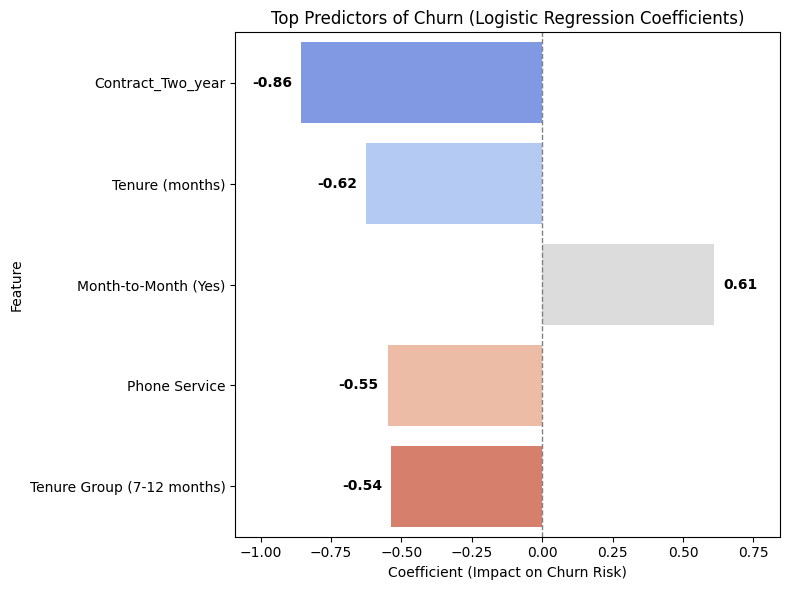

In [40]:
# Plot top predictors for churn from logistic regression model

top_n = 5
top_coef = coef_df.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.show()

### Comparison of Validation and Test Set Performance for Final Logistic Regression Model

The table below summarizes key metrics at the 0.50 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Note on terminology:**
- The "validation set" refers to the portion of the training data used during cross-validation to tune hyperparameters and select the best model. These results reflect model performance during development, before seeing the test set.
- The "test set" (also called the holdout set) is a separate, untouched dataset set aside at the start of the project. It is only used for the final evaluation after all model selection and tuning are complete, providing an unbiased estimate of real-world performance.


| Metric             | Validation Set | Test Set |
|--------------------|----------------|----------|
|Recall             | 0.80            | 0.79     |
|Precision          | 0.53            | 0.49     |
|ROC-AUC            | 0.845           | 0.837    |
|Confusion Matrix (% of actual class)   |                 |          |
|    - True Neg (TN)  | 73.9           | 70.76      |
|    - False Pos (FP) | 26.1           | 29.24      |
|    - False Neg (FN) | 18.86           | 21.12      |
|    - True Pos (TP)  | 81.14           | 78.88      |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.
